In [1]:
import warnings

warnings.filterwarnings("ignore")

import os  
import sys
parent =  os.path.join(os.getcwd(), 'package', 'synthdid')
dir = os.path.dirname(parent)
sys.path.append(dir)

import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
plt.style.use('ggplot')

from tqdm import tqdm

from synthdid.model import SynthDID


path = os.path.join(os.getcwd(), 'final_clean')
path2 = os.path.join(os.getcwd(), 'final_LaTeX')

pd.set_option('display.max_columns', None)

In [2]:
df = pd.read_csv(path + "/depreciation_dataset.csv")
df.head()

,country,year,brevets,NX,salary,gdp,pop,cho,ppa,public_spending,IDE,depreciation,ratio_dbrut
0,AUT,1996,9.610726,0.201729,-0.006855,-0.169498,8.982061,0.215484,-0.004415,0.041468,1.406747,0.056838,0.002113
1,AUT,1997,9.652395,-0.428677,-0.008273,-0.031561,8.983194,-0.025326,-0.002641,0.016204,-0.311722,0.056120,-0.003015
2,AUT,1998,9.730146,-0.104218,0.031968,0.627749,8.984291,0.065154,-0.009559,0.041098,0.670037,0.065051,-0.008570
3,AUT,1999,9.965429,-0.005612,0.022200,0.077027,8.986237,-0.143091,0.001231,0.048799,-0.346392,0.076619,-0.005696
4,AUT,2000,10.214788,-0.124520,0.003100,-0.152157,8.988642,-0.002762,-0.017752,0.052545,2.147245,0.089553,-0.000423


In [3]:
df = df[['year', 'country', 'depreciation', 'salary' , 'cho'  , 'ppa',  'IDE']]

In [4]:
df['country_code'] = pd.factorize(df['country'])[0] 
codes_df = df.copy()

def code(codes=codes_df) -> None:
    """
    Print country codes for AUT, FIN, and IRL, and list unique countries.
    """
    print("AUT code is = ", codes[codes['country'] == 'AUT']['country_code'].head(1).to_list(), "\n")
    print("FIN code is = ", codes[codes['country'] == 'FIN']['country_code'].head(1).to_list(), "\n")
    print("IRL code is = ", codes[codes['country'] == 'IRL']['country_code'].head(1).to_list(), "\n")
code()

AUT code is =  [0] 

FIN code is =  [1] 

IRL code is =  [2] 



In [5]:
df.columns

Index(['year', 'country', 'depreciation', 'salary', 'cho', 'ppa', 'IDE',
       'country_code'],
      dtype='object')

In [6]:
df =df.rename(columns={'country_code': 'state'})
df.head()

,year,country,depreciation,salary,cho,ppa,IDE,state
0,1996,AUT,0.056838,-0.006855,0.215484,-0.004415,1.406747,0
1,1997,AUT,0.056120,-0.008273,-0.025326,-0.002641,-0.311722,0
2,1998,AUT,0.065051,0.031968,0.065154,-0.009559,0.670037,0
3,1999,AUT,0.076619,0.022200,-0.143091,0.001231,-0.346392,0
4,2000,AUT,0.089553,0.003100,-0.002762,-0.017752,2.147245,0


In [7]:
df_ = df.pivot(index='state', columns="year")['depreciation'].T
df_.head()

state,0,1,2
year,,,
1996,0.056838,0.061627,0.156845
1997,0.056120,0.054293,0.201662
1998,0.065051,0.076765,0.198620
1999,0.076619,0.073383,0.225953
2000,0.089553,0.123173,0.244958


In [8]:
PRE_TEREM = [1999, 2015]
POST_TEREM = [2016, 2019]
TREATMENT = [2]  # "Treated country

sdid = SynthDID(df_, PRE_TEREM, POST_TEREM, TREATMENT)

In [9]:
sdid.fit(zeta_type="base", sparce_estimation=True)
hat_omega_simple = sdid.estimated_params(model="sc")
# hat_omega_elastic = sdid.estimated_params(model="ElasticNet")

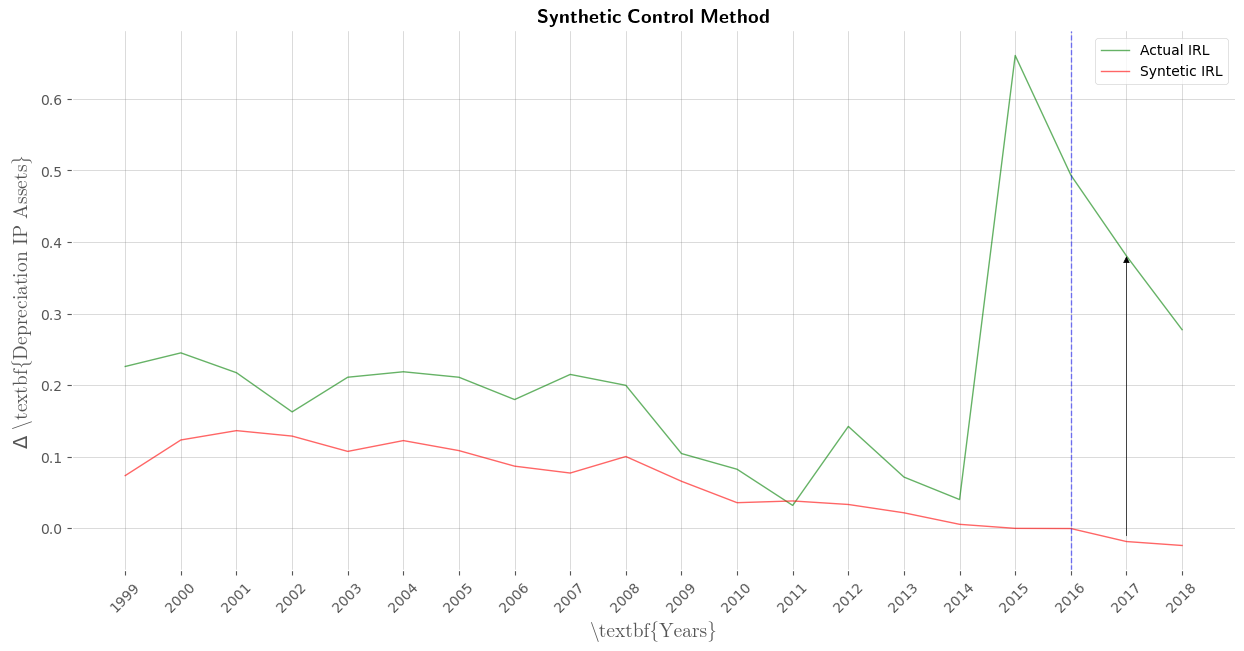

------------------------------------------------------------
Syntetic Control Method

point estimate: 0.398
0.3984795656785315


In [10]:
sdid.plot(model="sc")
# sdid.plot(model="did")

summary = sdid.summary(model="sc")
print(summary)

In [11]:
predicted = sdid.sdid_trajectory()
observed = sdid.target_y()
rmspe = ((observed - predicted) ** 2).mean() ** 0.5
print(f"RMSPE : {rmspe}")

RMSPE : 0.22797218422781754


In [12]:
hat_omega_sdid, _ = sdid.estimated_params()
print(hat_omega_sdid)
# Appeler la méthode comparison_plot
# sdid.comparison_plot(model="all", figsize=(10, 7))
weights_scm = sdid.hat_omega_ADH
weights_scm_df = pd.DataFrame(weights_scm, columns=['weights'])
weights_scm_df['weights'] = weights_scm_df['weights'].apply(lambda x: f"{x:.2e}")
# weights_scm_df.T.to_latex("/Users/jey/Desktop/Datascience/Latex/sdid/Brevets_weights_scm.tex")
print("\n", "weights_scm", weights_scm)
df_.head()

    features  sdid_weight
0          0        0.886
1          1        0.114
2  intercept        0.119

 weights_scm [5.55111512e-17 1.00000000e+00]


state,0,1,2
year,,,
1996,0.056838,0.061627,0.156845
1997,0.056120,0.054293,0.201662
1998,0.065051,0.076765,0.198620
1999,0.076619,0.073383,0.225953
2000,0.089553,0.123173,0.244958


In [17]:
weights_sc = sdid.hat_omega_ADH  # Poids SC (Synthetic Control)
control_units = sdid.control     # Liste des colonnes des unités de contrôle

weights_sc_dict = {unit: weight for unit, weight in zip(control_units, weights_sc)}

weights_sc_df = pd.DataFrame({'state_code': control_units, 'weight_sc': weights_sc.round(3)})
print(weights_sc_df)
code()


   state_code  weight_sc
0           0        0.0
1           1        1.0
AUT code is =  [0] 

FIN code is =  [1] 

IRL code is =  [2] 



In [16]:
tau_hat = sdid.hat_tau(model="sc")

b = {
    "RMSPE" : rmspe,
    "tau_hat" : tau_hat
}
b = pd.DataFrame(b, index=[0])

weights_sc_df.iloc[0,0:1] = 'AUT'
weights_sc_df.iloc[1,0:1] = 'FIN'

weights_sc_df



,state_code,weight_sc
0,AUT,0.0
1,FIN,1.0


In [15]:
b

,RMSPE,tau_hat
0,0.227972,0.39848


In [ ]:
# b.to_latex(path2 + "/tau_hat_depreciation.tex")
# weights_sc_df.to_latex(path2 + "/weights_depreciation.tex")